In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
from pathlib import Path
import joblib 


from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Visualization styling
plt.style.use("seaborn-v0_8-whitegrid")

In [3]:
DATA_PATH = Path("../data/processed/preprocessed_data.npz")

data = np.load(DATA_PATH)

X_train = data["X_train"]
X_test = data["X_test"]
Y_train = data["Y_train"]
Y_test = data["Y_test"]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {Y_train.shape}")
print(f"y_test shape: {Y_test.shape}")


X_train shape: (144415, 59)
X_test shape: (36104, 59)
y_train shape: (144415,)
y_test shape: (36104,)


In [13]:
models =  {
    "LogisticRegression" : LogisticRegression(max_iter=1000 , random_state=42 ) , 
    "RandomForestClassifier" : RandomForestClassifier(n_estimators= 100 , random_state=42 , n_jobs=-1),
    "XGBClassifier" : XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss", n_jobs=-1)
}

print(f"Defined {len(models)} models for benchmarking.")


Defined 3 models for benchmarking.


In [14]:
result_list =  []

for model_name , model in models.items():
    print(f"training {model_name} ...... ")


    model.fit(X_train , Y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(Y_test, y_pred)
    prec = precision_score(Y_test, y_pred)
    rec = recall_score(Y_test, y_pred)
    f1 = f1_score(Y_test, y_pred)
    roc_auc = roc_auc_score(Y_test, y_proba)

    result_list.append({
        "Model" : model_name , 
        "Accuracy" : acc , 
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
     })


print("all models trained. ")


training LogisticRegression ...... 


/Users/abdurrahmannassani/Documents/Projects/AI projrcts /30 practice project/ML practice  projects /Supply Chain Intelligence System/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


training RandomForestClassifier ...... 
training XGBClassifier ...... 
all models trained. 


In [15]:
results_df = pd.DataFrame(result_list).sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

results_df.style.highlight_max(axis=0, color="lightgreen")
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,RandomForestClassifier,0.732689,0.839411,0.633714,0.722201,0.818370
1,XGBClassifier,0.694327,0.773170,0.626238,0.691990,0.758488
2,LogisticRegression,0.694771,0.809581,0.579663,0.675596,0.743232


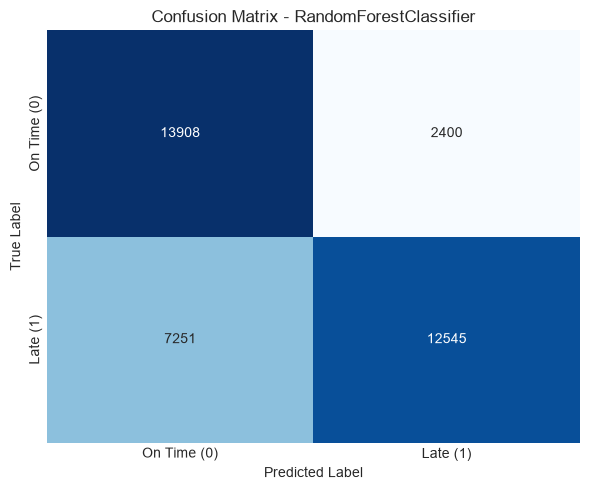

In [ ]:
# Select the top performing model 
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(Y_test, y_pred_best)






# Plot Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["On Time (0)", "Late (1)"],
            yticklabels=["On Time (0)", "Late (1)"])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [19]:
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = MODELS_DIR / "best_model.joblib"

joblib.dump(best_model , BEST_MODEL_PATH )

print(f"best model is {best_model} saved to : {BEST_MODEL_PATH}")

best model is RandomForestClassifier(n_jobs=-1, random_state=42) saved to : ../models/best_model.joblib
